In [15]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [16]:
import pandas as pd
import json
from collections import Counter
import numpy as np
import pandas as pd
import seaborn as sns
import spacy
import re
import pycountry
import sys
import copy as cp
from random import randrange, randint
import ast
import geopy as gpy
import itertools
import time
import datetime as dt
from shapely.geometry import Polygon, Point

import geopandas as gpd

# from src.text_processing_functions import *
from src.LLM_functions import *
from src.plot_functions import *
from src.data import *
from src.post_process_functions import *
from src.geocoding import *

#sys.path.append('/home/lhasbini/como_school/como_project4/src/')

In [17]:
#Select one report 
# all_reports = pd.read_csv(DATA_OUT_LLMS+'labelled_reports_response_llm_levels_haz_types_subtypes_impacts_geocoding.csv')
file_path = DATA_IN_JSONS +'all_ifrc_reports_info_unnested_with_text.json'#'nathaz_ifrc_reports_info_processed.json'

# Open and read the JSON file
with open(file_path, 'r') as json_file:
    ifrc_reports_processed = json.load(json_file)
all_reports = pd.DataFrame(ifrc_reports_processed)
all_reports = all_reports.rename({"location" : "country"}, axis=1)
# all_reports = all_reports.rename({"disasterTypeReclassified" : "hazardType"}, axis=1)

In [18]:
# Import data already geocoded 
save_name_labelled = "post_processed_labelled_reports_impacts_all_v240925"
df_labelled_geo_split = gpd.read_file(DATA_PATH + 'results_proc/'+save_name_labelled+'_geo_split_lowest_v250925.gpkg')

# Debug the code 

In [7]:
df_llm = pd.read_csv(DATA_PATH + 'results_proc/'+'post_processed_monty_200rep_meta-llama_llama-4-scout-17b-16e-instruct_v190925.csv', encoding='utf-8')

In [8]:
df = df_llm
similarity_th=0.2
split_lowest_levels=True
print_info=False
save_path=False
res_savename=False
polygon_source="geoBoundaries"

In [9]:
df_geo = deepcopy(df)

if "country_kw" in df_geo.columns : 
    col_to_list = ["location", "country", "country_kw", "country_iso3", "country_iso3_kw"]
    df_type = "llm"
else : 
    col_to_list = ["location", "country", "country_iso3"]
    df_type = "labelled"

for col in col_to_list : 
    df_geo[col] = df_geo[col].apply(
        lambda x: ast.literal_eval(x) if pd.notna(x) and isinstance(x, str) and x.strip().startswith("[") else ([x] if pd.notna(x) else None)
    )

# Open Polygons
gpd_files = open_admin_gpd(ADMIN_PATH, polygon_source)

In [93]:
top_row = -1

In [94]:
# Collect unique locations and associated countries
start = time.time()
unique_locations_countries = defaultdict(set)
unique_locations_countries_iso = defaultdict(set)

for _, row in df_geo.iterrows():
    # Handle countries 
    countries = row["country"]
    isos = row["country_iso3"]

    if not countries or not isos:
        isos = row["country_iso3_kw"]
        countries = row["country_kw"]

    # ensure iterable
    if not isinstance(countries, (list, set, tuple)):
        countries = [countries]
    if not isinstance(isos, (list, set, tuple)):
        isos = [isos]

    # Handle locations 
    locations = row["location"]
    if not locations:  
        for c, iso in zip(countries, isos):
            unique_locations_countries[c].update([c])
            unique_locations_countries_iso[c].update([iso])
    else : 
        for loc in row["location"]:
            unique_locations_countries[loc].update(countries)
            unique_locations_countries_iso[loc].update(isos)

unique_locations_countries = dict(unique_locations_countries)
unique_locations_countries_iso = dict(unique_locations_countries_iso)

end = time.time()
time_open = (end - start) / 60
print(f"Numer of unique locations : {len(unique_locations_countries)}")
print(f"Time to identify all locations {time_open}mins")

Numer of unique locations : 2455
Time to identify all locations 0.0015577038129170736mins


In [95]:
# Run nominatim for each loc 
start = time.time()
nom_loc_dict = {}
for loc in unique_locations_countries : 
    if loc not in nom_loc_dict:
        countries = unique_locations_countries[loc]
        countries_iso = unique_locations_countries_iso[loc]
        nom_loc_dict[loc] = find_best_nomin(loc, countries, countries_iso, similarity_th, print_info=False)
end = time.time()
time_open = (end - start) / 60
print(f"Time to nominatim all locations {time_open}mins")

Time to nominatim all locations 37.94808139801025mins


In [96]:
top_nom_loc = dict(list(nom_loc_dict.items())[:10])

In [97]:
top_nom_loc

{'Guatemala': (Location(Guatemala, (15.5855545, -90.345759, 0.0)),
  {'sim': 1.0,
   'admin_level': 0,
   'admin_field': 'ADMIN_0',
   'name': 'Guatemala',
   'key': 'country',
   'coords': (15.5855545, -90.345759),
   'country': 'Guatemala',
   'country_iso': 'GTM'}),
 'Honduras': (Location(Honduras, (15.2572432, -86.0755145, 0.0)),
  {'sim': 1.0,
   'admin_level': 0,
   'admin_field': 'ADMIN_0',
   'name': 'Honduras',
   'key': 'country',
   'coords': (15.2572432, -86.0755145),
   'country': 'Honduras',
   'country_iso': 'HND'}),
 'Nicaragua': (Location(Nicaragua, (12.3506436, -85.7841006, 0.0)),
  {'sim': 1.0,
   'admin_level': 0,
   'admin_field': 'ADMIN_0',
   'name': 'Nicaragua',
   'key': 'country',
   'coords': (12.3506436, -85.7841006),
   'country': 'Nicaragua',
   'country_iso': 'NIC'}),
 'Alta Verapaz': (Location(Alta Verapaz, Guatemala, (15.5949705, -90.0918031, 0.0)),
  {'sim': 1.0,
   'admin_level': 1,
   'admin_field': 'ADMIN_1',
   'name': 'Alta Verapaz',
   'key': 'st

In [98]:
start = time.time()
max_workers = min(10, (os.cpu_count() or 1) + 2)
df_geo_individual_locs = run_parallel_geocode(nom_loc_dict, unique_locations_countries, unique_locations_countries_iso, gpd_files, print_info=False, max_workers=max_workers)
end = time.time()
time_open = (end - start) / 60
print(f"Time to geocode all locations {time_open}mins")

Geocoding locations:  52%|█████▏    | 1266/2455 [00:26<00:24, 47.72it/s]

Error processing Ledia: cannot access local variable 'df_gpd' where it is not associated with a value


Geocoding locations: 100%|██████████| 2455/2455 [00:42<00:00, 58.21it/s] 


Time to geocode all locations 0.7198338429133098mins


In [106]:
#Test over a subset
nb_test = 1000

start = time.time()
max_workers = min(32, (os.cpu_count() or 1) * 2 + 4)
df_geo_output_1 = run_parallel_associate(df_geo.iloc[:nb_test], df_geo_individual_locs, gpd_files, split_lowest_levels=split_lowest_levels, polygon_source=polygon_source, max_workers=max_workers)
end = time.time()
time_open = (end - start) / 60
print(f"Time to gather locations per rows {time_open}mins")

Time to gather locations per rows 7.642123162746429mins


In [ ]:
#Test over a subset
start = time.time()
max_workers = min(32, (os.cpu_count() or 1) * 2 + 4)
df_geo_output_2 = run_parallel_associate(df_geo.iloc[1000:2000], df_geo_individual_locs, gpd_files, split_lowest_levels=split_lowest_levels, polygon_source=polygon_source, max_workers=max_workers)
end = time.time()
time_open = (end - start) / 60
print(f"Time to gather locations per rows {time_open}mins")

Time to gather locations per rows 11.044379429022472mins


In [108]:
#Test over a subset
start = time.time()
max_workers = min(32, (os.cpu_count() or 1) * 2 + 4)
df_geo_output_3 = run_parallel_associate(df_geo.iloc[2000:3000], df_geo_individual_locs, gpd_files, split_lowest_levels=split_lowest_levels, polygon_source=polygon_source, max_workers=max_workers)
end = time.time()
time_open = (end - start) / 60
print(f"Time to gather locations per rows {time_open}mins")

Time to gather locations per rows 6.778562259674072mins


In [109]:
#Test over a subset
start = time.time()
max_workers = min(32, (os.cpu_count() or 1) * 2 + 4)
df_geo_output_4 = run_parallel_associate(df_geo.iloc[3000:], df_geo_individual_locs, gpd_files, split_lowest_levels=split_lowest_levels, polygon_source=polygon_source, max_workers=max_workers)
end = time.time()
time_open = (end - start) / 60
print(f"Time to gather locations per rows {time_open}mins")

Time to gather locations per rows 2.0488754987716673mins


In [110]:
df_geo_output_all = pd.concat([df_geo_output_1, df_geo_output_2, df_geo_output_3, df_geo_output_4])

In [111]:
len(df_geo_output_all)

6065

In [ ]:
df_geo_output_all.head(10)

In [ ]:
start = time.time()
max_workers = min(32, (os.cpu_count() or 1) * 2 + 4)
df_geo_output = run_parallel_associate(df_geo, df_geo_individual_locs, gpd_files, split_lowest_levels=split_lowest_levels, polygon_source=polygon_source, max_workers=max_workers)
end = time.time()
time_open = (end - start) / 60
print(f"Time to gather locations per rows {time_open}mins")

Time to gather locations per rows 0.2424439787864685mins


In [71]:
df_geo_output.head(10)

,impactSubtype,impactValue,impactValueMin,impactValueMax,impactValuePrecision,impactUnit,valueAnnotation,country,location,locationAnnotation,...,country_iso3_kw,unit_type,geometry,locationLowestAdmin,geocoding_country_flag,geocoding_osm_flag,locationOsm,locationPolygon,iso3_code,impactValueApprox
0,Affected People,7500000.0,NaN,NaN,exact,people,['These two hurricanes affected more than7.5 m...,"[Guatemala, Honduras, Nicaragua]",[],['These two hurricanes affected more than7.5 m...,...,[PAN],other,MULTIPOLYGON (((-87.62557858700302 13.28992490...,ADM_0,0,0,"[Guatemala, Honduras, Nicaragua]","[Guatemala, Honduras, Nicaragua]","[GTM, HND, NIC]",NaN
1,Affected People,5000000.0,NaN,NaN,exact,people,['These departments are home to some five mill...,[Guatemala],"[Alta Verapaz, Izabal, Quiché, Huehuetenango, ...",['These departments are home to some five mill...,...,[PAN],other,MULTIPOLYGON (((-89.35678833102608 14.42261566...,ADM_1,0,0,"[Alta Verapaz, Izabal, Quiché, Huehuetenango, ...","[Alta Verapaz, Izabal, Quiché, Huehuetenango, ...",[GTM],NaN
2,Affected People,4700000.0,NaN,NaN,exact,people,['Approximately4.7 million people5 were affect...,[Honduras],"[Sula Valley, Copán, Choluteca, Comayagua, Cor...",['Hurricane Iota affected communities in the S...,...,[PAN],other,MULTIPOLYGON (((-87.61509880220186 13.27962137...,ADM_0,1,0,"[Honduras, Copán, Choluteca, Comayagua, Cortés...","[Honduras, Honduras, Honduras, Honduras, Hondu...",[HND],NaN
3,Affected People,NaN,NaN,NaN,exact,NaN,['Approximately4.7 million people5 were affect...,[Honduras],"[Sula Valley, Copán, Choluteca, Comayagua, Cor...",['Hurricane Iota affected communities in the S...,...,[PAN],other,MULTIPOLYGON (((-87.21703329169056 14.87622278...,ADM_1,0,0,"[Copán, Choluteca, Comayagua, Cortés, Yoro, At...","[Copán, Choluteca, Comayagua, Comayagua, Corté...",[HND],NaN
4,Affected People,NaN,NaN,NaN,exact,NaN,['Approximately4.7 million people5 were affect...,[Honduras],"[Sula Valley, Copán, Choluteca, Comayagua, Cor...",['Hurricane Iota affected communities in the S...,...,[PAN],other,MULTIPOLYGON (((-87.63148561041704 14.59472209...,ADM_2,0,0,[Comayagua],"[Comayagua, San Jose de Comayagua]",[HND],NaN
5,Affected People,3000000.0,NaN,NaN,exact,people,['The official government report9 issued on24 ...,[Nicaragua],[],['The official government report9 issued on24 ...,...,[PAN],other,MULTIPOLYGON (((-83.72691949935387 11.91307581...,ADM_0,0,0,[Nicaragua],[Nicaragua],[NIC],NaN
6,Displaced People,70000.0,NaN,NaN,exact,people,"['As a preventive measure, SINAPRED and other ...",[Nicaragua],[],"['As a preventive measure, SINAPRED and other ...",...,[PAN],other,MULTIPOLYGON (((-83.72691949935387 11.91307581...,ADM_0,0,0,[Nicaragua],[Nicaragua],[NIC],NaN
7,Human Deaths,NaN,NaN,NaN,NaN,people,['... dozens dead or missing in Central Americ...,"[Nicaragua, Honduras, Guatemala]",[],['... dozens dead or missing in Central Americ...,...,[PAN],other,MULTIPOLYGON (((-87.62557858700302 13.28992490...,ADM_0,0,0,"[Guatemala, Honduras, Nicaragua]","[Guatemala, Honduras, Nicaragua]","[GTM, HND, NIC]",NaN
8,Homeless People,1000.0,NaN,NaN,exact,people,"['Some1,000 homes were destroyed, more than6,0...",[Honduras],"[Sula Valley, Copán, Choluteca, Comayagua, Cor...",['Hurricane Iota affected communities in the S...,...,[PAN],other,MULTIPOLYGON (((-87.61509880220186 13.27962137...,ADM_0,1,0,"[Honduras, Copán, Choluteca, Comayagua, Cortés...","[Honduras, Honduras, Honduras, Honduras, Hondu...",[HND],NaN
9,Homeless People,NaN,NaN,NaN,exact,NaN,"['Some1,000 homes were destroyed, more than6,0...",[Honduras],"[Sula Valley, Copán, Choluteca, Comayagua, Cor...",['Hurricane Iota affected communities in the S...,...,[PAN],other,MULTIPOLYGON (((-87.21703329169056 14.87622278...,ADM_1,0,0,"[Copán, Choluteca, Comayagua, Cortés, Yoro, At...","[Copán, Choluteca, Comayagua, Comayagua, Corté...",[HND],NaN


In [ ]:
Error processing row 9: bad allocation

In [ ]:
# Save to final df 
res_savename = "post_processed_monty_200rep_meta-llama_llama-4-scout-17b-16e-instruct_v190925"
save_path = DATA_PATH
save_df = df_geo_output_all.copy()

save_df = delistify_cols(save_df)
save_gdf = gpd.GeoDataFrame(save_df, geometry='geometry')
save_gdf = save_gdf.set_crs("EPSG:4326", allow_override=True)
try:
    suffix = "_geo_split_lowest" if split_lowest_levels else "_geo"
    suffix = suffix + f"_v{dt.datetime.now().strftime('%d%m%y')}"

    #Save gpkg
    gpkg_path = save_path + f"{res_savename}{suffix}.gpkg"
    if not atomic_gpkg_save(save_gdf, gpkg_path):
        raise Exception(f"[GeoPackage Save Error] Failed to save GeoPackage to {gpkg_path}")
    # if os.path.exists(gpkg_path):
    #     os.remove(gpkg_path)
    # save_gdf.to_file(gpkg_path,
    #                 layer="multipolygons", driver="GPKG")

    # #Save shp
    # shp_path = f"{save_path}{res_savename}{suffix}.shp"
    # if os.path.exists(shp_path):
    #     os.remove(shp_path)
    # save_gdf.to_file(shp_path, driver="ESRI Shapefile")
except Exception as e:
    print(f"[GeoPackage Save Error] {e}")

# Convert location to polygons

In [175]:
#Post process files 
save_name_labelled = "post_processed_labelled_reports_impacts_all_v240925"
df_labelled = pd.read_csv(DATA_PATH + 'results_proc/'+save_name_labelled+'.csv', encoding='utf-8')

save_name_llm = "post_processed_labelled_reports_meta-llama_llama-4-scout-17b-16e-instruct_v230925"
df_llm = pd.read_csv(DATA_PATH + 'results_proc/'+save_name_llm+'.csv', encoding='utf-8')

# df_labelled = pd.read_csv(DATA_LABELLED + 'labelled_reports_impact_laura_18-08-25.csv', encoding='utf-8')


In [177]:
## Parallelized version 
similarity_th=0.2
similarity_polygon = 0.6
print_info=False
save_path = DATA_PATH + 'results_proc/'
split_lowest_levels = True

#For the llm version 
# res_savename = 'post_processed_llm_response_impact_labelled_reports_test_multiprompt_16rep_meta-llama_llama-4-scout-17b-16e-instruct'
# res_savename = "post_processed_llm_response_impact_labelled_reports_test_multiprompt_continue_16rep_meta-llama_llama-4-scout-17b-16e-instruct"

# df_llm_geo_split = geocode_df_to_polygon_v2_parrallel(df_llm, similarity_th=0.2, split_lowest_levels=split_lowest_levels, 
#                                          print_info=print_info, save_path=save_path, res_savename=False, 
#                                          polygon_source="geoBoundaries")

# # #Without splitting over highest admin levels 
# split_lowest_levels = False
# df_llm_geo = geocode_df_to_polygon_v2_parrallel(df_llm, similarity_th=0.2, split_lowest_levels=split_lowest_levels, 
#                                                 print_info=print_info, save_path=save_path, res_savename=res_savename, 
#                                                 polygon_source="geoBoundaries")

In [178]:
df_llm_geo_split = geocode_df_to_polygon_by_unique_loc(df_llm, similarity_th=0.2, split_lowest_levels=split_lowest_levels, 
                                                       print_info=print_info, save_path=save_path, res_savename=save_name_llm, 
                                                       polygon_source="geoBoundaries")

Numer of unique locations : 465
Time to identify all locations 0.0005614439646402995mins
Time to nominatim all locations 7.757808192571004mins


Geocoding locations: 100%|██████████| 465/465 [00:09<00:00, 49.45it/s] 


Time to geocode all locations 0.1748861829439799mins
Time to gather locations per rows 3.40986617008845mins


In [179]:
df_llm_geo_split.head(5)

,impactSubtype,impactValue,impactValueMin,impactValueMax,impactValuePrecision,impactUnit,valueAnnotation,country,location,locationAnnotation,...,country_iso3_kw,unit_type,geometry,locationLowestAdmin,geocoding_country_flag,geocoding_osm_flag,locationOsm,locationPolygon,iso3_code,impactValueApprox
0,Affected People,326788.0,NaN,NaN,exact,people,"['People Affected:326,788 people']",[Pakistan],"[Sindh, Balochistan, Khyber Pakhtunkhwa]",['Pakistan endured an exceptionally intense mo...,...,PAK,other,MULTIPOLYGON (((68.07458554208736 23.784985337...,ADM_1,0,0,"[Sindh, Balochistan, Khyber Pakhtunkhwa]","[Sindh, Balochistan, Khyber Pakhtunkhwa]",[PAK],NaN
1,Injured People,584.0,NaN,NaN,exact,people,['The monsoon season caused306 fatalities and5...,[Pakistan],"[Balochistan, Khyber Pakhtunkhwa, Sindh, Punja...",['Pakistan endured an exceptionally intense mo...,...,PAK,other,MULTIPOLYGON (((68.16838018529472 23.770647378...,ADM_0,2,0,"[Sindh, Balochistan, Khyber Pakhtunkhwa, Punja...","[Pakistan, Pakistan, Pakistan, Pakistan, Pakis...",[PAK],NaN
2,Injured People,NaN,NaN,NaN,exact,NaN,['The monsoon season caused306 fatalities and5...,[Pakistan],"[Balochistan, Khyber Pakhtunkhwa, Sindh, Punja...",['Pakistan endured an exceptionally intense mo...,...,PAK,other,MULTIPOLYGON (((68.07540854914413 23.785859876...,ADM_1,0,0,"[Sindh, Balochistan, Khyber Pakhtunkhwa, Punjab]","[Sindh, Balochistan, Khyber Pakhtunkhwa, Punjab]",[PAK],NaN
3,Human Deaths,306.0,NaN,NaN,exact,people,['The monsoon season caused306 fatalities and5...,[Pakistan],"[Balochistan, Khyber Pakhtunkhwa, Sindh, Punja...",['The monsoon season caused306 fatalities and5...,...,PAK,other,MULTIPOLYGON (((68.16838018529472 23.770647378...,ADM_0,1,0,"[Sindh, Balochistan, Khyber Pakhtunkhwa, Punja...","[Pakistan, Pakistan, Pakistan, Pakistan, Pakis...",[PAK],NaN
4,Human Deaths,NaN,NaN,NaN,exact,NaN,['The monsoon season caused306 fatalities and5...,[Pakistan],"[Balochistan, Khyber Pakhtunkhwa, Sindh, Punja...",['The monsoon season caused306 fatalities and5...,...,PAK,other,MULTIPOLYGON (((68.07540854914413 23.785859876...,ADM_1,0,0,"[Sindh, Balochistan, Khyber Pakhtunkhwa, Punja...","[Sindh, Balochistan, Khyber Pakhtunkhwa, Punja...",[PAK],NaN


In [180]:
df_labelled_geo_split = geocode_df_to_polygon_by_unique_loc(df_labelled, similarity_th=0.2, split_lowest_levels=split_lowest_levels, 
                                         print_info=print_info, save_path=save_path, res_savename=save_name_labelled, 
                                         polygon_source="geoBoundaries")

Numer of unique locations : 375
Time to identify all locations 0.0003375569979349772mins
Time to nominatim all locations 6.0309938033421835mins


Geocoding locations: 100%|██████████| 375/375 [00:05<00:00, 64.30it/s] 


Time to geocode all locations 0.11020206610361735mins
Time to gather locations per rows 2.0214510361353555mins


In [188]:
# Save as well without the split 
split_lowest_levels = False 
df_llm_geo = geocode_df_to_polygon_by_unique_loc(df_llm, similarity_th=0.2, split_lowest_levels=split_lowest_levels, 
                                                    print_info=print_info, save_path=save_path, res_savename=save_name_llm, 
                                                    polygon_source="geoBoundaries")
df_labelled_geo = geocode_df_to_polygon_by_unique_loc(df_labelled, similarity_th=0.2, split_lowest_levels=split_lowest_levels, 
                                                    print_info=print_info, save_path=save_path, res_savename=save_name_labelled, 
                                                    polygon_source="geoBoundaries")

Numer of unique locations : 465
Time to identify all locations 0.001050392786661784mins
Time to nominatim all locations 7.3855682452519735mins


Geocoding locations: 100%|██████████| 465/465 [00:11<00:00, 41.02it/s]


Time to geocode all locations 0.20050251881281536mins
Time to gather locations per rows 3.097464724381765mins
Numer of unique locations : 375
Time to identify all locations 0.00026660760243733724mins
Time to nominatim all locations 6.264220670859019mins


Geocoding locations: 100%|██████████| 375/375 [00:07<00:00, 51.45it/s]


Time to geocode all locations 0.13113361597061157mins
Time to gather locations per rows 1.965146525700887mins


In [7]:
# Try to geocode the 200 reports 
save_name_llm_3_1_8b = "post_processed_labelled_reports_llama-3.1-8b-instant_v250925"
df_llm_3_1_8b = pd.read_csv(DATA_PATH + 'results_proc/'+save_name_llm_3_1_8b+'.csv', encoding='utf-8')

# Fix code arguments 
similarity_th=0.2
similarity_polygon = 0.6
print_info=False
save_path = DATA_PATH + 'results_proc/'

# Run geocoding 
df_llm_3_1_8b_geo_split, df_llm_3_1_8b_geo = geocode_df_to_polygon_by_unique_loc(df_llm_3_1_8b, similarity_th=0.2, 
                                                    print_info=print_info, save_path=save_path, res_savename=save_name_llm_3_1_8b, 
                                                    polygon_source="geoBoundaries")

Numer of unique locations : 483
Time to identify all locations 0.00034447511037190753mins
Time to nominatim all locations 7.081032876173655mins


Geocoding locations: 100%|██████████| 483/483 [00:05<00:00, 87.58it/s] 


Time to geocode all locations 0.09942998091379801mins
Time to gather locations per rows 2.4885570367177325mins
Time to gather locations per rows 3.248711399237315mins


In [20]:
# Try to geocode the 200 reports 
save_name_llm_3_3_70b = "post_processed_labelled_reports_llama-3.3-70b-versatile_v250925"
df_llm_3_3_70b = pd.read_csv(DATA_PATH + 'results_proc/'+save_name_llm_3_3_70b+'.csv', encoding='utf-8')

# Fix code arguments 
similarity_th=0.2
similarity_polygon = 0.6
print_info=False
save_path = DATA_PATH + 'results_proc/'

# Run geocoding 
df_llm_3_3_70b_geo_split, df_llm_3_3_70b_geo = geocode_df_to_polygon_by_unique_loc(df_llm_3_3_70b, similarity_th=0.2, 
                                                    print_info=print_info, save_path=save_path, res_savename=save_name_llm_3_3_70b, 
                                                    polygon_source="geoBoundaries")

Numer of unique locations : 428
Time to identify all locations 0.0002834200859069824mins
Time to nominatim all locations 6.922057064374288mins


Geocoding locations: 100%|██████████| 428/428 [00:06<00:00, 65.58it/s] 


Time to geocode all locations 0.11725715001424154mins
Time to gather locations per rows 1.9488394816716512mins
Time to gather locations per rows 1.7393595298131308mins


In [19]:
# Try to geocode the 200 reports 
save_name_llm_200 = "post_processed_monty_200rep_meta-llama_llama-4-scout-17b-16e-instruct_v190925"
df_llm_200 = pd.read_csv(DATA_PATH + 'results_proc/'+save_name_llm_200+'.csv', encoding='utf-8')

# Fix code arguments 
similarity_th=0.2
similarity_polygon = 0.6
print_info=False
save_path = DATA_PATH + 'results_proc/'

# Run geocoding 
df_llm_200_geo_split, df_llm_200_geo = geocode_df_to_polygon_by_unique_loc(df_llm_200, similarity_th=0.2, 
                                                    print_info=print_info, save_path=save_path, res_savename=save_name_llm_200, 
                                                    polygon_source="geoBoundaries")

Numer of unique locations : 2444
Time to identify all locations 0.0025448163350423178mins
Time to nominatim all locations 37.61219708919525mins


Geocoding locations:  52%|█████▏    | 1264/2444 [00:38<00:28, 41.52it/s]

Error processing Ledia: cannot access local variable 'df_gpd' where it is not associated with a value


Geocoding locations: 100%|██████████| 2444/2444 [01:00<00:00, 40.68it/s] 


Time to geocode all locations 1.0382773836453756mins
Time to gather locations per rows 31.671779171625772mins
Time to gather locations per rows 32.23096677859624mins


# Quality of the geocoding

## For all the reports 

In [ ]:
df_geo_output_all_haz = df_geo_output_all.copy()
df_geo_output_all_haz["hazards"] = df_geo_output_all_haz["hazards"].apply(
    lambda x: ast.literal_eval(x) if pd.notna(x) and isinstance(x, str) and x.strip().startswith("[") else ([x] if pd.notna(x) else None)
)

In [142]:
df_geo_output_all_haz.head(5)

,impactSubtype,impactValue,impactValueMin,impactValueMax,impactValuePrecision,impactUnit,valueAnnotation,country,location,locationAnnotation,...,country_iso3_kw,unit_type,geometry,locationLowestAdmin,geocoding_country_flag,geocoding_osm_flag,locationOsm,locationPolygon,iso3_code,impactValueApprox
0,Affected People,7500000.0,NaN,NaN,exact,people,['These two hurricanes affected more than7.5 m...,"[Guatemala, Honduras, Nicaragua]",[],['These two hurricanes affected more than7.5 m...,...,[PAN],other,MULTIPOLYGON (((-87.62557858700302 13.28992490...,ADM_0,0,0,"[Guatemala, Honduras, Nicaragua]","[Guatemala, Honduras, Nicaragua]","[GTM, HND, NIC]",NaN
1,Affected People,5000000.0,NaN,NaN,exact,people,['These departments are home to some five mill...,[Guatemala],"[Alta Verapaz, Izabal, Quiché, Huehuetenango, ...",['These departments are home to some five mill...,...,[PAN],other,MULTIPOLYGON (((-89.35678833102608 14.42261566...,ADM_1,0,0,"[Alta Verapaz, Izabal, Quiché, Huehuetenango, ...","[Alta Verapaz, Izabal, Quiché, Huehuetenango, ...",[GTM],NaN
2,Affected People,4700000.0,NaN,NaN,exact,people,['Approximately4.7 million people5 were affect...,[Honduras],"[Sula Valley, Copán, Choluteca, Comayagua, Cor...",['Hurricane Iota affected communities in the S...,...,[PAN],other,MULTIPOLYGON (((-87.61509880220186 13.27962137...,ADM_0,3,1,"[Guatemala, Copán, Choluteca, Cortés, Atlántid...","[Guatemala, Honduras, Guatemala, Guatemala, Gu...","[GTM, HND]",NaN
3,Affected People,NaN,NaN,NaN,exact,NaN,['Approximately4.7 million people5 were affect...,[Honduras],"[Sula Valley, Copán, Choluteca, Comayagua, Cor...",['Hurricane Iota affected communities in the S...,...,[PAN],other,POLYGON ((-88.81259074180367 15.26272895280895...,ADM_1,0,1,"[Copán, Choluteca, Cortés, Atlántida, Santa Bá...","[Copán, Guatemala, Quiché, Suchitepéquez, Guat...","[HND, GTM]",NaN
4,Affected People,NaN,NaN,NaN,exact,NaN,['Approximately4.7 million people5 were affect...,[Honduras],"[Sula Valley, Copán, Choluteca, Comayagua, Cor...",['Hurricane Iota affected communities in the S...,...,[PAN],other,POLYGON ((-90.83722955990996 16.79570605312295...,ADM_2,0,1,"[Choluteca, Atlántida, Colón]","[Guatemala, Quiché, El Palmar]",[GTM],NaN


In [ ]:
df_geo_all_exploded = df_geo_output_all_haz.explode("locationPolygon")
df_geo_all_exploded["locationPolygon"] = (
    df_geo_all_exploded["locationPolygon"]
    .apply(lambda x: x if isinstance(x, str) else str(x))
)
df_geo_all_exploded_haz = df_geo_all_exploded.explode("hazards")

counts_hazard_admin = (
    df_geo_all_exploded_haz
    .groupby(["hazards", "locationLowestAdmin"])["locationPolygon"]
    # .nunique()
    .count()
    .unstack(fill_value=0)  # ADM_0, ADM_1, ADM_2 as columns
    .reindex(columns=["ADM_0", "ADM_1", "ADM_2"], fill_value=0)
)

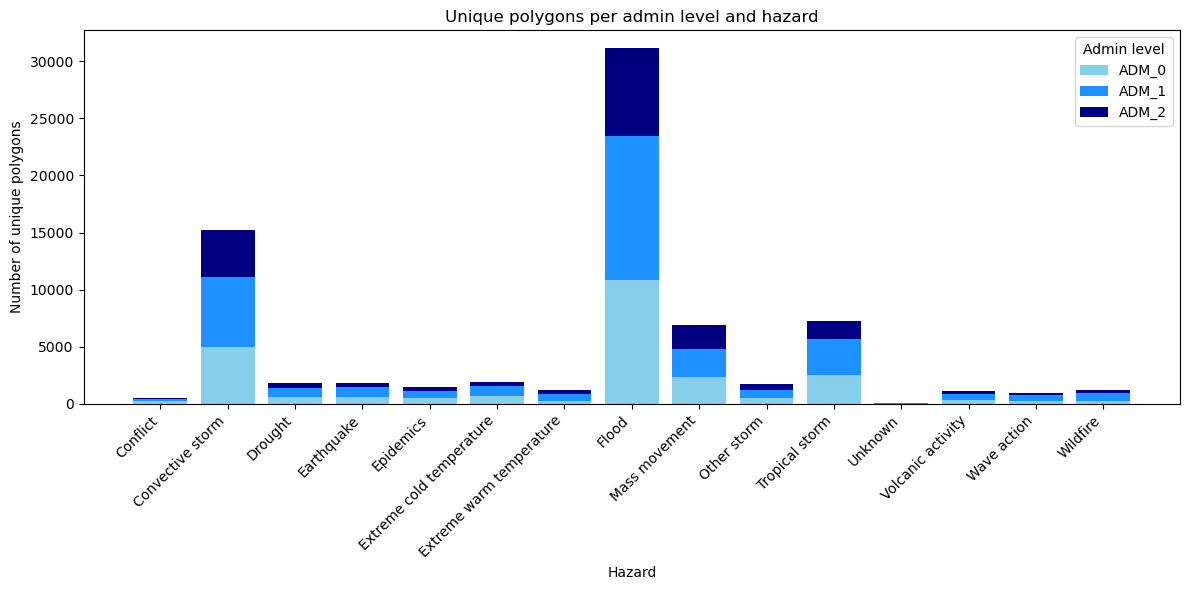

In [140]:
# --- Plot stacked bars ---
hazards = counts_hazard_admin.index
x = np.arange(len(hazards))

levels = ["ADM_0", "ADM_1", "ADM_2"]
colors = ["skyblue", "dodgerblue", "navy"]

fig, ax = plt.subplots(figsize=(12,6))

bottom = np.zeros(len(hazards))
for level, color in zip(levels, colors):
    ax.bar(x, counts_hazard_admin[level], label=level, color=color, bottom=bottom)
    bottom += counts_hazard_admin[level]

ax.set_xticks(x)
ax.set_xticklabels(hazards, rotation=45, ha="right")
ax.set_ylabel("Number of unique polygons")
ax.set_xlabel("Hazard")
ax.set_title("Unique polygons per admin level and hazard")
ax.legend(title="Admin level")

plt.tight_layout()
plt.show()

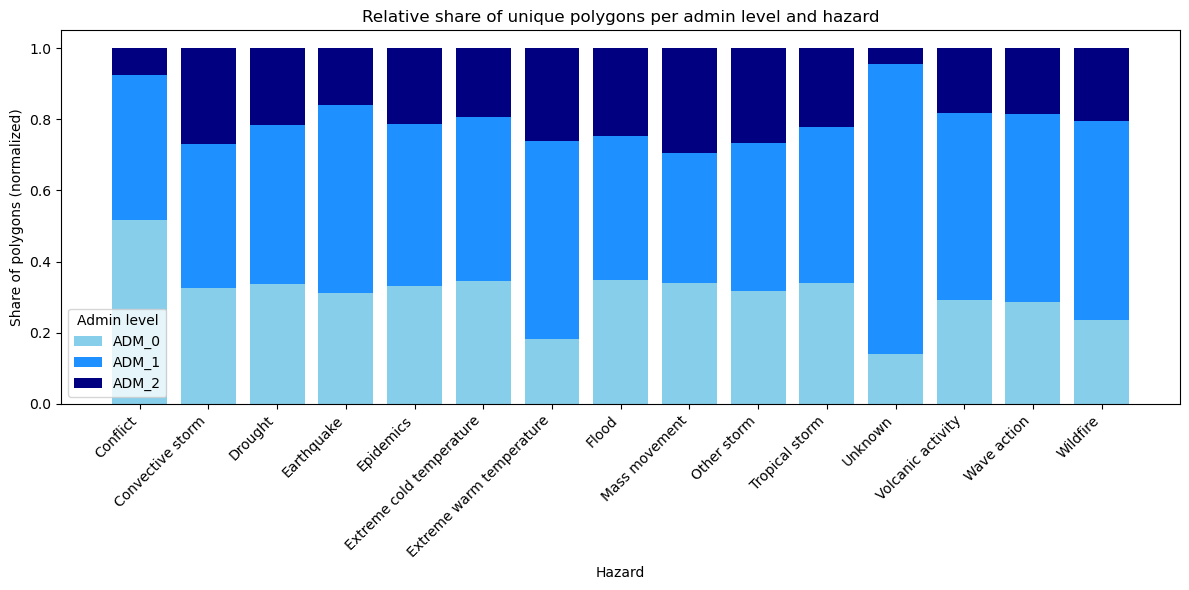

In [151]:
counts_hazard_admin_pct = counts_hazard_admin.div(counts_hazard_admin.sum(axis=1), axis=0)
# --- Plot stacked bars (normalized) ---
hazards = counts_hazard_admin_pct.index
x = np.arange(len(hazards))

levels = ["ADM_0", "ADM_1", "ADM_2"]
colors = ["skyblue", "dodgerblue", "navy"]

fig, ax = plt.subplots(figsize=(12,6))

bottom = np.zeros(len(hazards))
for level, color in zip(levels, colors):
    ax.bar(x, counts_hazard_admin_pct[level], label=level, color=color, bottom=bottom)
    bottom += counts_hazard_admin_pct[level]

ax.set_xticks(x)
ax.set_xticklabels(hazards, rotation=45, ha="right")
ax.set_ylabel("Share of polygons (normalized)")
ax.set_xlabel("Hazard")
ax.set_title("Relative share of unique polygons per admin level and hazard")
ax.legend(title="Admin level")

plt.tight_layout()
plt.show()

### Per country 

In [ ]:
df_geo_all_exploded_country.loc[df_geo_all_exploded_country["iso3_code"]=="IND"]["appealCode"].unique()

array(['MDRBD020'], dtype=object)

In [171]:
df_geo_output_all.loc[df_geo_output_all["appealCode"]=="MDRBD020"]

,impactSubtype,impactValue,impactValueMin,impactValueMax,impactValuePrecision,impactUnit,valueAnnotation,country,location,locationAnnotation,...,country_iso3_kw,unit_type,geometry,locationLowestAdmin,geocoding_country_flag,geocoding_osm_flag,locationOsm,locationPolygon,iso3_code,impactValueApprox
1334,Affected People,6900000.0,NaN,NaN,exact,people,['According to the report from the National Di...,[Bangladesh],[riverine region],"['In August2017, heavy monsoon rains above the...",...,[BGD],other,MULTIPOLYGON (((91.8853723525898 21.9641304507...,ADM_2,0,1,[Riverine Restaurant],[Chittagong],[BGD],NaN
1335,Displaced People,297254.0,NaN,NaN,exact,people,['The death toll reported was114 people and297...,[Bangladesh],[],['According to the report from the National Di...,...,[BGD],other,MULTIPOLYGON (((89.25366241980777 21.693580546...,ADM_0,0,0,[Bangladesh],[Bangladesh],[BGD],NaN
1336,Human Deaths,114.0,NaN,NaN,exact,people,['The death toll reported was114 people and297...,[Bangladesh],[],['According to the report from the National Di...,...,[BGD],other,MULTIPOLYGON (((89.25366241980777 21.693580546...,ADM_0,0,0,[Bangladesh],[Bangladesh],[BGD],NaN
1337,Residential Buildings,593247.0,NaN,NaN,exact,homes,['According to the report from the National Di...,[Bangladesh],[],['According to the report from the National Di...,...,[BGD],other,MULTIPOLYGON (((89.25366241980777 21.693580546...,ADM_0,0,0,[Bangladesh],[Bangladesh],[BGD],NaN
1338,"Access to Water, Sanitation, and Hygiene",NaN,NaN,NaN,NaN,NaN,['The Water and Sanitation facilities of the a...,[Bangladesh],"[Lalmonirhat district, Moheshkhocha union in L...",['The target union for the assessment was Mohe...,...,[BGD],other,MULTIPOLYGON (((89.2819220104468 21.6939777908...,ADM_0,2,1,"[Lalmonirhat District, Bangladesh]","[Bangladesh, Bangladesh, Bangladesh]",[BGD],NaN
1339,"Access to Water, Sanitation, and Hygiene",NaN,NaN,NaN,NaN,NaN,['The Water and Sanitation facilities of the a...,[Bangladesh],"[Lalmonirhat district, Moheshkhocha union in L...",['The target union for the assessment was Mohe...,...,[BGD],other,MULTIPOLYGON (((88.18488959043799 25.801312869...,ADM_1,0,1,[Lalmonirhat District],[Rangpur],[BGD],NaN
1340,Access to Food,NaN,NaN,NaN,NaN,NaN,"['Besides, in the aftermath of the flood in201...",[Bangladesh],[],"['Besides, in the aftermath of the flood in201...",...,[BGD],other,MULTIPOLYGON (((89.25366241980777 21.693580546...,ADM_0,0,0,[Bangladesh],[Bangladesh],[BGD],NaN
1341,Human Health and Wellbeing,NaN,NaN,NaN,NaN,NaN,['Water borne disease are common phenomena in ...,[Bangladesh],"[Lalmonirhat district, Moheshkhocha under Adit...",['The target union for the assessment was Mohe...,...,[BGD],other,MULTIPOLYGON (((89.25478205493613 21.695318490...,ADM_0,1,1,"[Lalmonirhat District, Bangladesh]","[Bangladesh, Bangladesh]",[BGD],NaN
1342,Human Health and Wellbeing,NaN,NaN,NaN,NaN,NaN,['Water borne disease are common phenomena in ...,[Bangladesh],"[Lalmonirhat district, Moheshkhocha under Adit...",['The target union for the assessment was Mohe...,...,[BGD],other,MULTIPOLYGON (((88.18488959043799 25.801312869...,ADM_1,0,1,[Lalmonirhat District],[Rangpur],[BGD],NaN
1343,Residential Buildings,6500.0,NaN,NaN,exact,km**2 of crop production and forestry,['According to the report from the National Di...,"[Bangladesh, India, Nepal, Bhutan]",[],"['In August2017, heavy monsoon rains above the...",...,[BGD],km**2,MULTIPOLYGON (((73.02831320872136 8.2645597881...,ADM_0,0,0,"[Bangladesh, India, Nepal, Bhutan]","[Bangladesh, India, Nepal, Bhutan]","[BGD, IND, NPL, BTN]",NaN


In [166]:
df_geo_all_exploded_country.loc[df_geo_all_exploded_country["iso3_code"]=="FRA"]["locationAnnotation"].iloc[28]

"['In cases where hosting is unsuccessful, a key threat is bad press in the media which can lead to a fuelling of anti-migrant sentiments.']"

In [162]:
df_geo_all_exploded_country.loc[df_geo_all_exploded_country["iso3_code"]=="FRA"]["locationAnnotation"].iloc[9]

'[\'The program operates in various EU countries,1 supported by the European Commission\\\'s "Safe Homes Guidance”2 and funded by the Asylum Migration and Integration Fund.\']'

In [159]:
df_geo_all_exploded_country.loc[df_geo_all_exploded_country["iso3_code"]=="FRA"][["appealCode", "country", "country_iso3", "location", "country_kw", "country_iso3_kw"]].head(3)

,appealCode,country,country_iso3,location,country_kw,country_iso3_kw
277,MDRBJ008,"[France, Belgium, Luxembourg, Slovakia, Nether...","[FRA, BEL, LUX, SVK, NLD, HUN, IRL, LUX, POL]",[],[Benin],[BEN]
277,MDRBJ008,"[France, Belgium, Luxembourg, Slovakia, Nether...","[FRA, BEL, LUX, SVK, NLD, HUN, IRL, LUX, POL]",[],[Benin],[BEN]
277,MDRBJ008,"[France, Belgium, Luxembourg, Slovakia, Nether...","[FRA, BEL, LUX, SVK, NLD, HUN, IRL, LUX, POL]",[],[Benin],[BEN]


In [ ]:
df_geo_all_exploded_country.loc[df_geo_all_exploded_country["iso3_code"]=="FRA"][["appealCode", "country", "country_iso3", "location", "country_kw", "country_iso3_kw"]]

In [147]:
# 1. Group and count (no .nunique, just raw count)
df_geo_all_exploded_country = df_geo_all_exploded.explode("iso3_code")

counts_country_admin = (
    df_geo_all_exploded_country
    .groupby(["iso3_code", "locationLowestAdmin"])["locationPolygon"]
    .count()
    .unstack(fill_value=0)
    .reindex(columns=["ADM_0", "ADM_1", "ADM_2"], fill_value=0)
)

# 2. Convert to % per country
counts_country_admin_pct = counts_country_admin.div(
    counts_country_admin.sum(axis=1), axis=0
) * 100

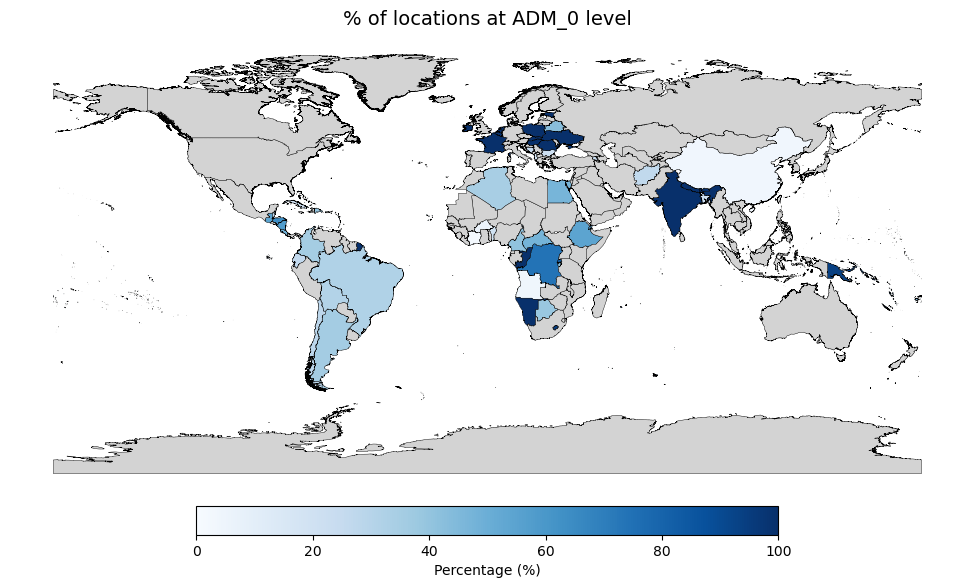

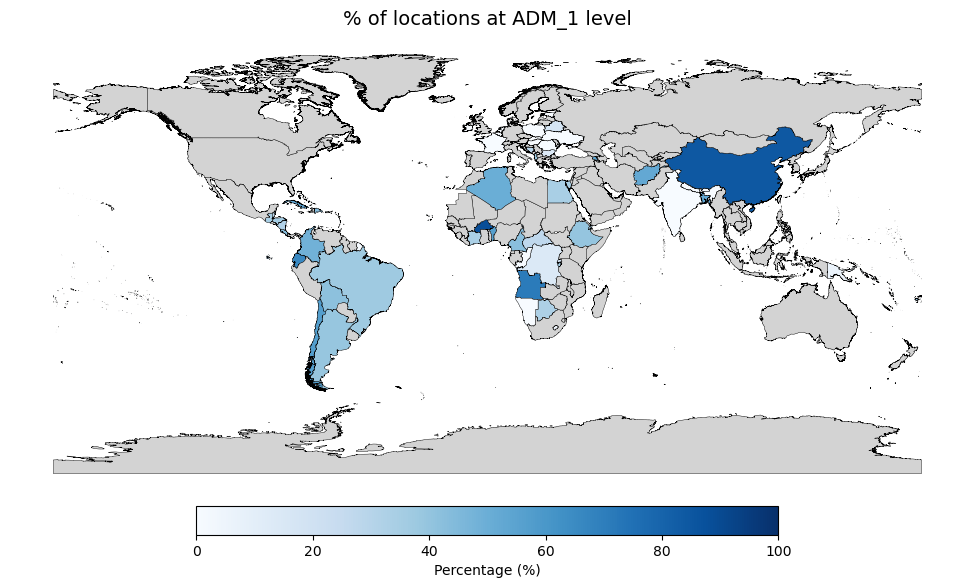

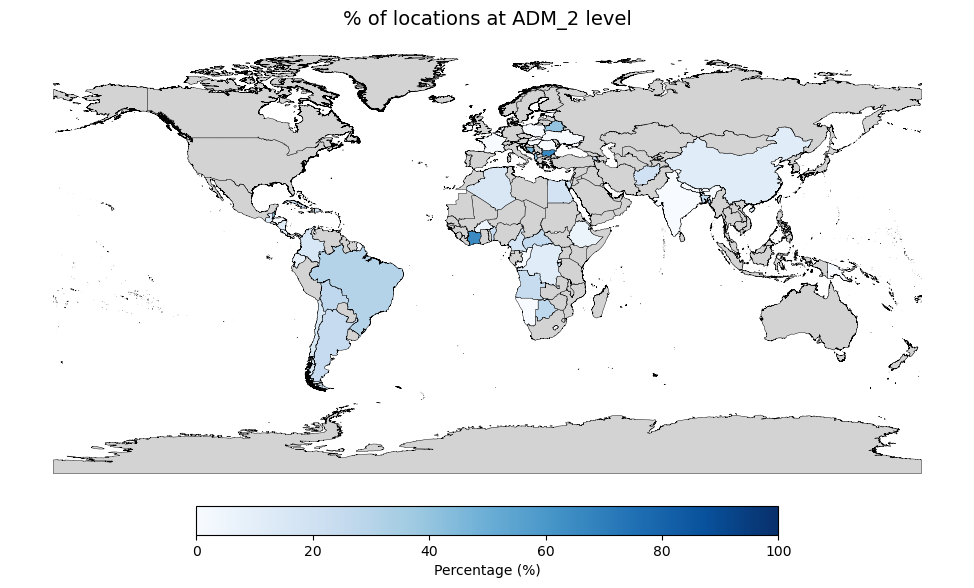

In [150]:
# 3. Load world geometries (you mentioned you have a GADM geopackage for all countries)
world = gpd_files['ADM_0']

# 4. Merge with iso3_code
world = world.merge(counts_country_admin_pct, left_on="iso3_code", right_index=True, how="left")

# 5. Plot individual maps with horizontal colorbar
levels = ["ADM_0", "ADM_1", "ADM_2"]
titles = [
    "% of locations at ADM_0 level",
    "% of locations at ADM_1 level",
    "% of locations at ADM_2 level"
]

for level, title in zip(levels, titles):
    fig, ax = plt.subplots(figsize=(10,6))
    world.plot(
        column=level, ax=ax, legend=True,
        cmap="Blues", edgecolor="black", linewidth=0.3,
        missing_kwds={"color": "lightgrey"},
        vmin=0, vmax=100,
        legend_kwds={
            "orientation": "horizontal",
            "shrink": 0.6,
            "pad": 0.02,
            "label": "Percentage (%)"
        }
    )
    ax.set_title(title, fontsize=14)
    ax.axis("off")
    plt.tight_layout()
    plt.show()

## For the labelled report 

- For each appealCode : 
    - Number of unique locations found 
    - Over this locations, split between the ones geocoded and the level at which they have been geocoded (ADM_0/ADM_1/ADM_2)

In [12]:
def prepare_counts(df):
    df_exploded = df.explode("locationPolygon")
    df_exploded["locationPolygon"] = (
        df_exploded["locationPolygon"].apply(lambda x: x if isinstance(x, str) else str(x))
    )
    counts = (
        df_exploded
        .groupby(["appealCode", "locationLowestAdmin"])["locationPolygon"]
        .nunique()
        .unstack(fill_value=0)  # wide format
        .reindex(columns=["ADM_0", "ADM_1", "ADM_2"], fill_value=0)  # enforce order
    )
    return counts

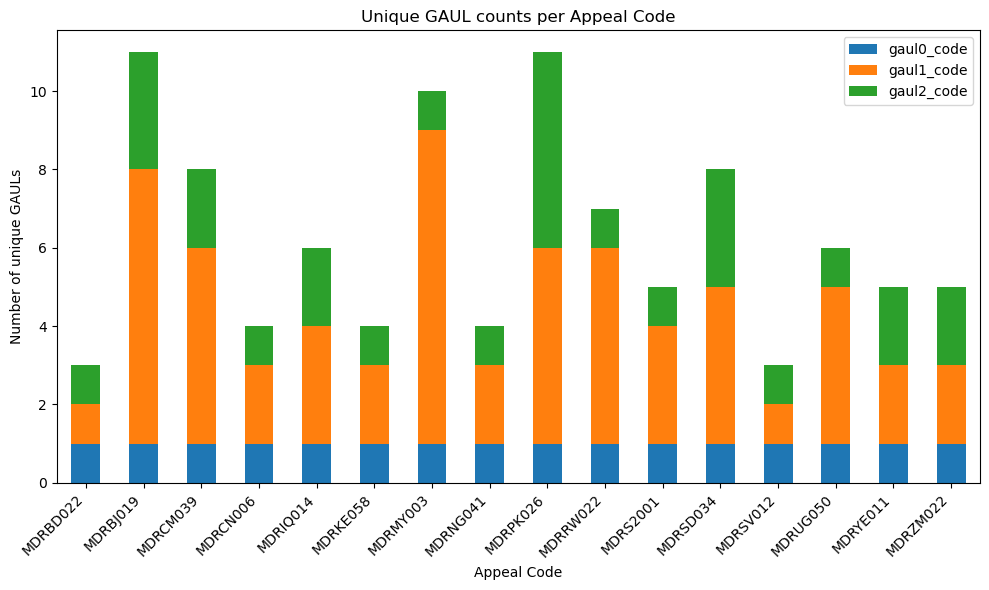

In [31]:
def count_unique_lists(series):
    all_elements = set()
    for lst in series:
        if isinstance(lst, list):
            all_elements.update(lst)
    return len(all_elements)

# Prepare the data
plot_data = df_llm_geo.groupby('appealCode').agg({
    'gaul0_code': count_unique_lists,
    'gaul1_code': count_unique_lists,
    'gaul2_code': count_unique_lists
})

# Plot
ax = plot_data.plot(kind='bar', stacked=True, figsize=(10,6))
ax.set_ylabel("Number of unique GAULs")
ax.set_xlabel("Appeal Code")
ax.set_title("Unique GAUL counts per Appeal Code")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

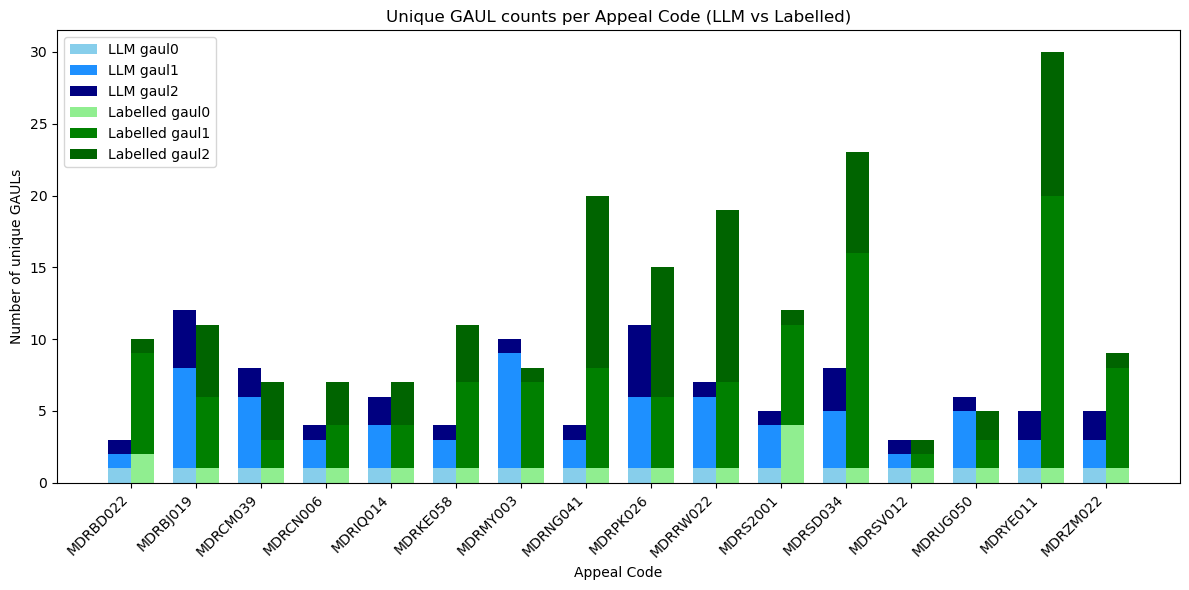

In [83]:
import numpy as np
import matplotlib.pyplot as plt

# Function to count unique elements in lists per group
def count_unique_lists(series):
    all_elements = set()
    for lst in series:
        if isinstance(lst, list):
            all_elements.update(lst)
    return len(all_elements)

# Aggregate data for both datasets
plot_data_llm = df_llm_geo.groupby('appealCode').agg({
    'gaul0_code': count_unique_lists,
    'gaul1_code': count_unique_lists,
    'gaul2_code': count_unique_lists
})

plot_data_labelled = df_labelled_geo.groupby('appealCode').agg({
    'gaul0_code': count_unique_lists,
    'gaul1_code': count_unique_lists,
    'gaul2_code': count_unique_lists
})

# Make sure both have the same appealCodes in the same order
all_codes = sorted(set(plot_data_llm.index) | set(plot_data_labelled.index))
plot_data_llm = plot_data_llm.reindex(all_codes, fill_value=0)
plot_data_labelled = plot_data_labelled.reindex(all_codes, fill_value=0)

# Set bar positions
x = np.arange(len(all_codes))
width = 0.35  # width of each bar

# Plot
fig, ax = plt.subplots(figsize=(12,6))

# LLM bars
ax.bar(x - width/2, plot_data_llm['gaul0_code'], width, label='LLM gaul0', color='skyblue', bottom=0)
ax.bar(x - width/2, plot_data_llm['gaul1_code'], width, label='LLM gaul1', color='dodgerblue', bottom=plot_data_llm['gaul0_code'])
bottom_llm = plot_data_llm['gaul0_code'] + plot_data_llm['gaul1_code']
ax.bar(x - width/2, plot_data_llm['gaul2_code'], width, label='LLM gaul2', color='navy', bottom=bottom_llm)

# Labelled bars
ax.bar(x + width/2, plot_data_labelled['gaul0_code'], width, label='Labelled gaul0', color='lightgreen', bottom=0)
ax.bar(x + width/2, plot_data_labelled['gaul1_code'], width, label='Labelled gaul1', color='green', bottom=plot_data_labelled['gaul0_code'])
bottom_labelled = plot_data_labelled['gaul0_code'] + plot_data_labelled['gaul1_code']
ax.bar(x + width/2, plot_data_labelled['gaul2_code'], width, label='Labelled gaul2', color='darkgreen', bottom=bottom_labelled)

# Labels
ax.set_xticks(x)
ax.set_xticklabels(all_codes, rotation=45, ha='right')
ax.set_ylabel("Number of unique GAULs")
ax.set_xlabel("Appeal Code")
ax.set_title("Unique GAUL counts per Appeal Code (LLM vs Labelled)")
ax.legend(loc='upper left')
plt.tight_layout()
fig.savefig(DATA_FIGURE+'counts_unique_loc_admin_appealCode_llm-labelled.png', dpi=300, bbox_inches='tight', transparent=True)

In [183]:
df_llm_exploded = df_llm_geo_split.explode("locationPolygon")
df_llm_exploded["locationPolygon"] = (
    df_llm_exploded["locationPolygon"]
    .apply(lambda x: x if isinstance(x, str) else str(x))
)
counts_llm = (
    df_llm_exploded
    .groupby(["appealCode", "locationLowestAdmin"])["locationPolygon"]
    .nunique()
    .unstack(fill_value=0)              # wide format: columns = ADM_0, ADM_1, ADM_2
    .reindex(columns=["ADM_0", "ADM_1", "ADM_2"], fill_value=0)  # ensure order
)

df_labelled_exploded = df_labelled_geo_split.explode("locationPolygon")
df_labelled_exploded["locationPolygon"] = (
    df_labelled_exploded["locationPolygon"]
    .apply(lambda x: x if isinstance(x, str) else str(x))
)
counts_labelled = (
    df_labelled_exploded
    .groupby(["appealCode", "locationLowestAdmin"])["locationPolygon"]
    .nunique()
    .unstack(fill_value=0)              # wide format: columns = ADM_0, ADM_1, ADM_2
    .reindex(columns=["ADM_0", "ADM_1", "ADM_2"], fill_value=0)  # ensure order
)

In [186]:
counts_labelled

locationLowestAdmin,ADM_0,ADM_1,ADM_2
appealCode,,,
MDRBD022,2,6,2
MDRBJ019,1,7,4
MDRCM039,1,2,2
MDRCN006,1,2,2
MDRCO023,1,0,0
MDRDZ011,0,7,0
MDRGE019,1,3,25
MDRGT009,1,0,0
MDRGW003,1,0,0


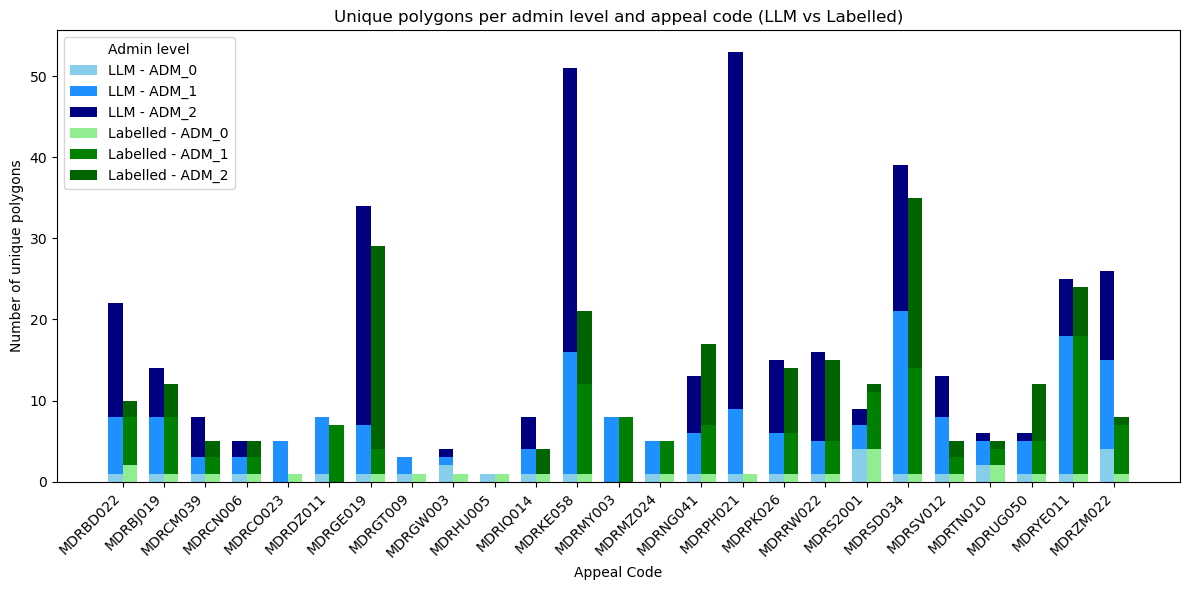

In [184]:
# Build shared index of all appealCodes
all_appeal_codes = counts_llm.index.union(counts_labelled.index)

# Reindex both DataFrames to have the same index (fill missing with 0)
counts_llm = counts_llm.reindex(all_appeal_codes, fill_value=0)
counts_labelled = counts_labelled.reindex(all_appeal_codes, fill_value=0)

### PLOT
levels = ["ADM_0", "ADM_1", "ADM_2"]
colors_llm = ["skyblue", "dodgerblue", "navy"]
colors_labelled = ["lightgreen", "green", "darkgreen"]

x = np.arange(len(all_appeal_codes))  # one bar per appealCode
width = 0.35

fig, ax = plt.subplots(figsize=(12,6))

# LLM bars
bottom = np.zeros(len(all_appeal_codes))
for level, color in zip(levels, colors_llm):
    ax.bar(x - width/2, counts_llm[level], width, label=f"LLM - {level}", color=color, bottom=bottom)
    bottom += counts_llm[level]

# Labelled bars
bottom = np.zeros(len(all_appeal_codes))
for level, color in zip(levels, colors_labelled):
    ax.bar(x + width/2, counts_labelled[level], width, label=f"Labelled - {level}", color=color, bottom=bottom)
    bottom += counts_labelled[level]

# Labels
ax.set_xticks(x)
ax.set_xticklabels(all_appeal_codes, rotation=45, ha="right")
ax.set_ylabel("Number of unique polygons")
ax.set_xlabel("Appeal Code")
ax.set_title("Unique polygons per admin level and appeal code (LLM vs Labelled)")
ax.legend(title="Admin level", loc="upper left")

plt.tight_layout()
plt.show()


In [13]:
# Compute counts for the 3 datasets
counts_llm_8b = prepare_counts(df_llm_3_1_8b_geo_split)
counts_llm_70b = prepare_counts(df_llm_3_3_70b_geo_split)
counts_labelled = prepare_counts(df_labelled_geo_split)

# Shared appealCode index
all_appeal_codes = (
    counts_llm_8b.index
    .union(counts_llm_70b.index)
    .union(counts_labelled.index)
)
counts_llm_8b = counts_llm_8b.reindex(all_appeal_codes, fill_value=0)
counts_llm_70b = counts_llm_70b.reindex(all_appeal_codes, fill_value=0)
counts_labelled = counts_labelled.reindex(all_appeal_codes, fill_value=0)

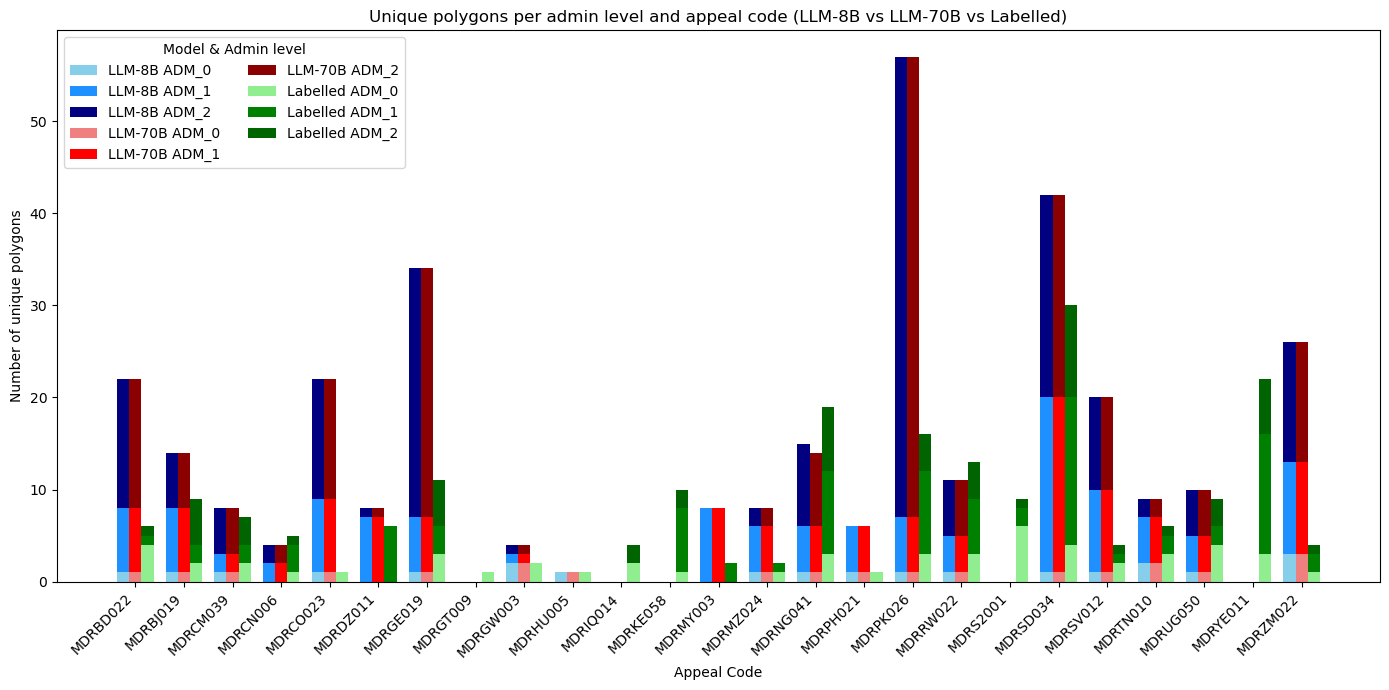

In [14]:
# Plot setup
levels = ["ADM_0", "ADM_1", "ADM_2"]

colors_8b = ["skyblue", "dodgerblue", "navy"]
colors_70b = ["lightcoral", "red", "darkred"]
colors_labelled = ["lightgreen", "green", "darkgreen"]

x = np.arange(len(all_appeal_codes))  # bar positions
width = 0.25  # narrower, to fit 3 bars

fig, ax = plt.subplots(figsize=(14,7))

# LLM 8B bars
bottom = np.zeros(len(all_appeal_codes))
for level, color in zip(levels, colors_8b):
    ax.bar(x - width, counts_llm_8b[level], width, label=f"LLM-8B {level}", color=color, bottom=bottom)
    bottom += counts_llm_8b[level]

# LLM 70B bars
bottom = np.zeros(len(all_appeal_codes))
for level, color in zip(levels, colors_70b):
    ax.bar(x, counts_llm_70b[level], width, label=f"LLM-70B {level}", color=color, bottom=bottom)
    bottom += counts_llm_70b[level]

# Labelled bars
bottom = np.zeros(len(all_appeal_codes))
for level, color in zip(levels, colors_labelled):
    ax.bar(x + width, counts_labelled[level], width, label=f"Labelled {level}", color=color, bottom=bottom)
    bottom += counts_labelled[level]

# Labels
ax.set_xticks(x)
ax.set_xticklabels(all_appeal_codes, rotation=45, ha="right")
ax.set_ylabel("Number of unique polygons")
ax.set_xlabel("Appeal Code")
ax.set_title("Unique polygons per admin level and appeal code (LLM-8B vs LLM-70B vs Labelled)")
ax.legend(title="Model & Admin level", loc="upper left", ncol=2)

plt.tight_layout()
plt.show()

In [ ]:
# Also add information about the number of flag raised 
df_llm_exploded = df_llm_geo_split.explode("locationPolygon")
df_llm_exploded["locationPolygon"] = (
    df_llm_exploded["locationPolygon"]
    .apply(lambda x: x if isinstance(x, str) else str(x))
)
counts_llm = (
    df_llm_exploded
    .groupby(["appealCode", "locationLowestAdmin"])["locationPolygon"]
    .nunique()
    .unstack(fill_value=0)              # wide format: columns = ADM_0, ADM_1, ADM_2
    .reindex(columns=["ADM_0", "ADM_1", "ADM_2"], fill_value=0)  # ensure order
)

df_labelled_exploded = df_labelled_geo_split.explode("locationPolygon")
df_labelled_exploded["locationPolygon"] = (
    df_labelled_exploded["locationPolygon"]
    .apply(lambda x: x if isinstance(x, str) else str(x))
)
counts_labelled = (
    df_labelled_exploded
    .groupby(["appealCode", "locationLowestAdmin"])["locationPolygon"]
    .nunique()
    .unstack(fill_value=0)              # wide format: columns = ADM_0, ADM_1, ADM_2
    .reindex(columns=["ADM_0", "ADM_1", "ADM_2"], fill_value=0)  # ensure order
)

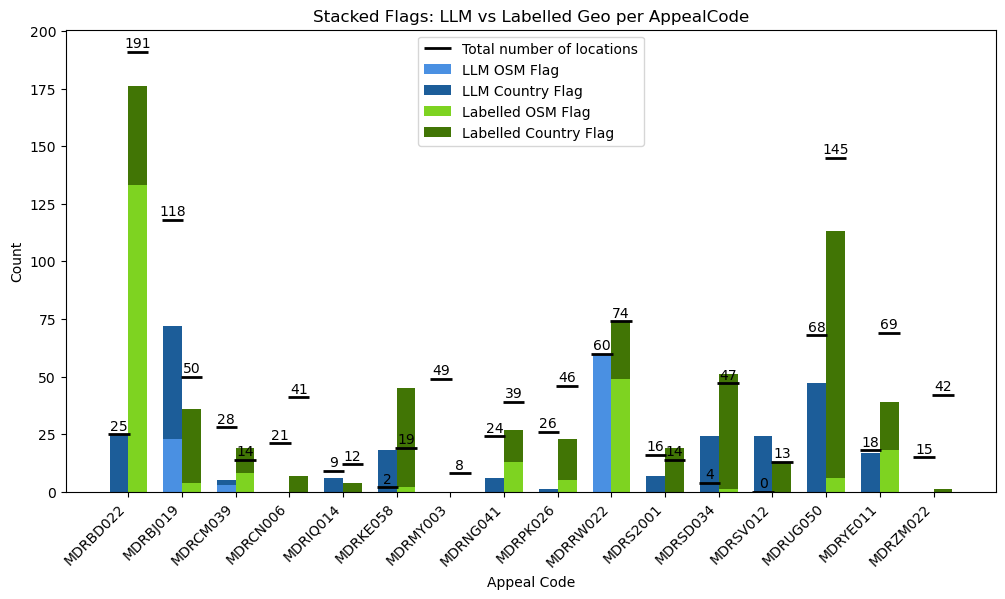

In [ ]:
# Compute number of locations per row
for df in [df_llm_geo_split, df_labelled_geo]:
    df['num_locations'] = df['location'].apply(len)

# Group by appealCode
grouped_llm = df_llm_geo_split.groupby('appealCode').agg({
    'num_locations': 'sum',
    'geocoding_osm_flag': 'sum',
    'geocoding_country_flag': 'sum'
}).reset_index()

grouped_labelled = df_labelled_geo.groupby('appealCode').agg({
    'num_locations': 'sum',
    'geocoding_osm_flag': 'sum',
    'geocoding_country_flag': 'sum'
}).reset_index()

# Set bar width and positions
bar_width = 0.35
x = np.arange(len(grouped_llm['appealCode']))

fig, ax = plt.subplots(figsize=(12,6))

# Colors
llm_colors = ['#4A90E2', '#1C5D99']       # Light blue, dark blue
labelled_colors = ['#7ED321', '#417505']  # Light green, dark green

# LLM bars
ax.bar(x - bar_width/2, grouped_llm['geocoding_osm_flag'], bar_width, color=llm_colors[0], label='LLM OSM Flag')
ax.bar(x - bar_width/2, grouped_llm['geocoding_country_flag'], bar_width, 
       bottom=grouped_llm['geocoding_osm_flag'], color=llm_colors[1], label='LLM Country Flag')

# Labelled bars
ax.bar(x + bar_width/2, grouped_labelled['geocoding_osm_flag'], bar_width, color=labelled_colors[0], label='Labelled OSM Flag')
ax.bar(x + bar_width/2, grouped_labelled['geocoding_country_flag'], bar_width, 
       bottom=grouped_labelled['geocoding_osm_flag'], color=labelled_colors[1], label='Labelled Country Flag')

# Plot total reports as lines
for i in range(len(x)):
    ax.hlines(y=grouped_llm['num_locations'][i], xmin=i - bar_width/2 - 0.2, xmax=i - bar_width/2 + 0.2, 
              color='black', lw=2, label='Total number of locations' if i==0 else "")
    ax.text(i - bar_width/2, grouped_llm['num_locations'][i] + 0.5, str(grouped_llm['num_locations'][i]), 
            ha='center', va='bottom', fontsize=10)
    
    ax.hlines(y=grouped_labelled['num_locations'][i], xmin=i + bar_width/2 - 0.2, xmax=i + bar_width/2 + 0.2, 
              color='black', lw=2)
    ax.text(i + bar_width/2, grouped_labelled['num_locations'][i] + 0.5, str(grouped_labelled['num_locations'][i]), 
            ha='center', va='bottom', fontsize=10)

# Formatting
ax.set_xticks(x)
ax.set_xticklabels(grouped_llm['appealCode'], rotation=45, ha='right')
ax.set_ylabel('Count')
ax.set_xlabel('Appeal Code')
ax.set_title('Stacked Flags: LLM vs Labelled Geo per AppealCode')
ax.legend()
# fig.savefig(DATA_FIGURE+'counts_flags_appealCode_llm-labelled.png', dpi=300, bbox_inches='tight', transparent=True)
